# Working with Jupyter Notebooks
In this notebook we are going to work with Jupyter Notebooks. We will:
1. Load exported TF query files into a `pandas` dataframe
2. Do some data mining operations
3. Visualize some of our data results

# Getting the Data-Analysis workbench ready

## Loading Data-Analysis tools

In [1]:
import sys, os, collections
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt; plt.rcdefaults()
from matplotlib.pyplot import figure
from collections import Counter

## Importing our TF query results
We are now going to import the tsv files that we exported in our last tutorial.

In [ ]:
#BHSAbrahamSearch=pd.read_csv('D:/OneDrive - Andrews University/1200_AUS-research/Fabric-TEXT/BHSAbrahamSearch.tsv',delimiter='\t',encoding='utf-16')

BHSAbrahamSearch=pd.read_csv('~/Desktop/course_TF-Workshop/data_export/BHSAbrahamSearch.tsv',delimiter='\t',encoding='utf-16')
pd.set_option('display.max_columns', 50)
BHSAbrahamSearch.head(11)

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex1,lex_utf81,sp1
0,1,Genesis,11,26,5366,word,אַבְרָ֔ם,>BRM/,אברם,nmpr
1,2,Genesis,11,27,5379,word,אַבְרָ֔ם,>BRM/,אברם,nmpr
2,3,Genesis,11,29,5405,word,אַבְרָ֧ם,>BRM/,אברם,nmpr
3,4,Genesis,11,29,5412,word,אַבְרָם֙,>BRM/,אברם,nmpr
4,5,Genesis,11,31,5437,word,אַבְרָ֣ם,>BRM/,אברם,nmpr
5,6,Genesis,11,31,5451,word,אַבְרָ֣ם,>BRM/,אברם,nmpr
6,7,Genesis,12,1,5488,word,אַבְרָ֔ם,>BRM/,אברם,nmpr
7,8,Genesis,12,4,5533,word,אַבְרָ֗ם,>BRM/,אברם,nmpr
8,9,Genesis,12,4,5544,word,אַבְרָ֗ם,>BRM/,אברם,nmpr
9,10,Genesis,12,5,5557,word,אַבְרָם֩,>BRM/,אברם,nmpr


In [ ]:
#NTAbrahamSearch=pd.read_csv('D:/OneDrive - Andrews University/1200_AUS-research/Fabric-TEXT/NTAbrahamSearch.tsv',delimiter='\t',encoding='utf-16')
NTAbrahamSearch=pd.read_csv('~/Desktop/course_TF-Workshop/data_export/NTAbrahamSearch.tsv',delimiter='\t',encoding='utf-16')
pd.set_option('display.max_columns', 50)
NTAbrahamSearch.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lemma1,lemmatranslit1
0,1,Matthew,1,1,8,word,Ἀβραάμ.,Ἀβραάμ,Abraam
1,2,Matthew,1,2,9,word,Ἀβραὰμ,Ἀβραάμ,Abraam
2,3,Matthew,1,17,252,word,Ἀβραὰμ,Ἀβραάμ,Abraam
3,4,Matthew,3,9,1033,word,Ἀβραάμ·,Ἀβραάμ,Abraam
4,5,Matthew,3,9,1048,word,Ἀβραάμ.,Ἀβραάμ,Abraam


# Some simple data mining operations
## `groupby` particular *column* by `sum` and  `count`

In [4]:
BHSAbrahamSearch.groupby(["lex1"]).sum()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex_utf81,sp1
lex1,,,,,,,,,
>BRHM/,25742,GenesisGenesisGenesisGenesisGenesisGenesisGene...,4209,2704,10028251,wordwordwordwordwordwordwordwordwordwordwordwo...,אַבְרָהָ֔ם אַבְרָהָ֔ם אַבְרָהָ֔ם אַבְרָהָ֛ם אַ...,אברהםאברהםאברהםאברהםאברהםאברהםאברהםאברהםאברהםא...,nmprnmprnmprnmprnmprnmprnmprnmprnmprnmprnmprnm...
>BRM/,2224,GenesisGenesisGenesisGenesisGenesisGenesisGene...,829,684,1155657,wordwordwordwordwordwordwordwordwordwordwordwo...,אַבְרָ֔ם אַבְרָ֔ם אַבְרָ֧ם אַבְרָם֙ אַבְרָ֣ם א...,אברםאברםאברםאברםאברםאברםאברםאברםאברםאברםאברםאב...,nmprnmprnmprnmprnmprnmprnmprnmprnmprnmprnmprnm...


In [5]:
BHSAbrahamSearch.groupby(["lex1"]).count()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex_utf81,sp1
lex1,,,,,,,,,
>BRHM/,175,175,175,175,175,175,175,175,175
>BRM/,61,61,61,61,61,61,61,61,61


In [6]:
BHSAbrahamSearch.groupby(["lex1"]).count().sum()

R            236
S1           236
S2           236
S3           236
NODE1        236
TYPE1        236
TEXT1        236
lex_utf81    236
sp1          236
dtype: int64

In [7]:
NTAbrahamSearch.groupby(["S1"]).count()

,R,S2,S3,NODE1,TYPE1,TEXT1,lemma1,lemmatranslit1
S1,,,,,,,,
Acts,7,7,7,7,7,7,7,7
Galatians,9,9,9,9,9,9,9,9
Hebrews,10,10,10,10,10,10,10,10
II_Corinthians,1,1,1,1,1,1,1,1
I_Peter,1,1,1,1,1,1,1,1
James,2,2,2,2,2,2,2,2
John,11,11,11,11,11,11,11,11
Luke,15,15,15,15,15,15,15,15
Mark,1,1,1,1,1,1,1,1


## `groupby` particular *column* by `count` and `sort_values`

In [8]:
NTAbrahamSearch.groupby(['S1']).count().sort_values(['TEXT1'], ascending=False)

,R,S2,S3,NODE1,TYPE1,TEXT1,lemma1,lemmatranslit1
S1,,,,,,,,
Luke,15,15,15,15,15,15,15,15
John,11,11,11,11,11,11,11,11
Hebrews,10,10,10,10,10,10,10,10
Galatians,9,9,9,9,9,9,9,9
Romans,9,9,9,9,9,9,9,9
Acts,7,7,7,7,7,7,7,7
Matthew,7,7,7,7,7,7,7,7
James,2,2,2,2,2,2,2,2
II_Corinthians,1,1,1,1,1,1,1,1


## Finding a value with `==`

In [9]:
BHSAbrahamSearch[(BHSAbrahamSearch['lex1'] == '>BRM/')]

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex1,lex_utf81,sp1
0,1,Genesis,11,26,5366,word,אַבְרָ֔ם,>BRM/,אברם,nmpr
1,2,Genesis,11,27,5379,word,אַבְרָ֔ם,>BRM/,אברם,nmpr
2,3,Genesis,11,29,5405,word,אַבְרָ֧ם,>BRM/,אברם,nmpr
3,4,Genesis,11,29,5412,word,אַבְרָם֙,>BRM/,אברם,nmpr
4,5,Genesis,11,31,5437,word,אַבְרָ֣ם,>BRM/,אברם,nmpr
...,...,...,...,...,...,...,...,...,...,...
56,57,Genesis,17,1,7337,word,אַבְרָ֗ם,>BRM/,אברם,nmpr
57,58,Genesis,17,3,7364,word,אַבְרָ֖ם,>BRM/,אברם,nmpr
58,59,Genesis,17,5,7389,word,אַבְרָ֑ם,>BRM/,אברם,nmpr
225,226,Nehemiah,9,7,387898,word,אַבְרָ֔ם,>BRM/,אברם,nmpr


## Finding a value with `!=`

In [10]:
BHSAbrahamSearch[(BHSAbrahamSearch['lex1'] != '>BRM/')]

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex1,lex_utf81,sp1
59,60,Genesis,17,5,7393,word,אַבְרָהָ֔ם,>BRHM/,אברהם,nmpr
60,61,Genesis,17,9,7464,word,אַבְרָהָ֔ם,>BRHM/,אברהם,nmpr
61,62,Genesis,17,15,7567,word,אַבְרָהָ֔ם,>BRHM/,אברהם,nmpr
62,63,Genesis,17,17,7599,word,אַבְרָהָ֛ם,>BRHM/,אברהם,nmpr
63,64,Genesis,17,18,7624,word,אַבְרָהָ֖ם,>BRHM/,אברהם,nmpr
...,...,...,...,...,...,...,...,...,...,...
231,232,1_Chronicles,1,34,391598,word,אַבְרָהָ֖ם,>BRHM/,אברהם,nmpr
232,233,1_Chronicles,16,16,399832,word,אַבְרָהָ֔ם,>BRHM/,אברהם,nmpr
233,234,1_Chronicles,29,18,406532,word,אַבְרָהָ֞ם,>BRHM/,אברהם,nmpr
234,235,2_Chronicles,20,7,416130,word,אַבְרָהָ֥ם,>BRHM/,אברהם,nmpr


## Finding values with `&` 

In [11]:
BHSAbrahamSearch[
          (BHSAbrahamSearch['lex1'] == '>BRM/')
        & (BHSAbrahamSearch['S1'] != 'Genesis')
                ]

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex1,lex_utf81,sp1
225,226,Nehemiah,9,7,387898,word,אַבְרָ֔ם,>BRM/,אברם,nmpr
227,228,1_Chronicles,1,27,391522,word,אַבְרָ֖ם,>BRM/,אברם,nmpr


In [12]:
BHSAbrahamSearch[
          (BHSAbrahamSearch['lex1'] == '>BRM/')
        & (BHSAbrahamSearch['R'] > 50 )
                ]

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex1,lex_utf81,sp1
50,51,Genesis,16,6,7141,word,אַבְרָ֜ם,>BRM/,אברם,nmpr
51,52,Genesis,16,15,7298,word,אַבְרָ֖ם,>BRM/,אברם,nmpr
52,53,Genesis,16,15,7302,word,אַבְרָ֧ם,>BRM/,אברם,nmpr
53,54,Genesis,16,16,7310,word,אַבְרָ֕ם,>BRM/,אברם,nmpr
54,55,Genesis,16,16,7323,word,אַבְרָֽם׃ ס,>BRM/,אברם,nmpr
55,56,Genesis,17,1,7326,word,אַבְרָ֔ם,>BRM/,אברם,nmpr
56,57,Genesis,17,1,7337,word,אַבְרָ֗ם,>BRM/,אברם,nmpr
57,58,Genesis,17,3,7364,word,אַבְרָ֖ם,>BRM/,אברם,nmpr
58,59,Genesis,17,5,7389,word,אַבְרָ֑ם,>BRM/,אברם,nmpr
225,226,Nehemiah,9,7,387898,word,אַבְרָ֔ם,>BRM/,אברם,nmpr


In [13]:
BHSAbrahamSearch[
          (BHSAbrahamSearch['lex1'] == '>BRM/')
        & (BHSAbrahamSearch['S1'] == 'Genesis')
        & (BHSAbrahamSearch['S2'] > 17 )
                ]

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,lex1,lex_utf81,sp1


In Genesis "Abram" does not appear after chapter 17.

# Data Visualization
## Simple Bar Plotting

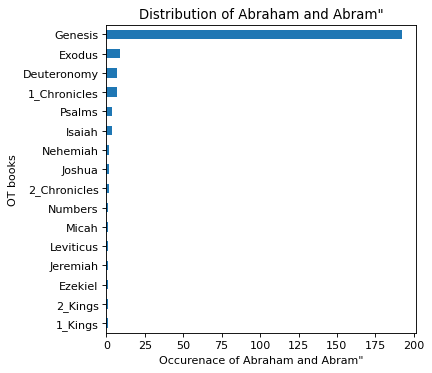

In [14]:
figure(num=None, figsize=(5, 5), dpi=80, facecolor='w', edgecolor='k')
BHSAbrahamSearch.groupby("S1").size().sort_values(ascending=True).plot.barh()

plt.title('Distribution of Abraham and Abram"')

plt.xlabel('Occurenace of Abraham and Abram"')
plt.ylabel('OT books')

plt.show()

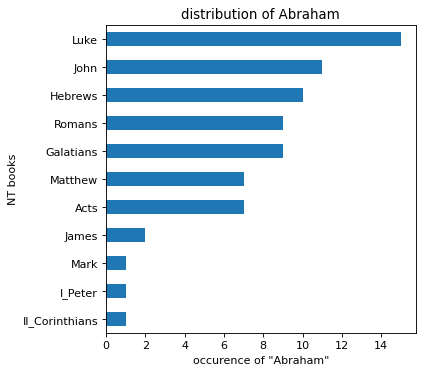

In [15]:
figure(num=None, figsize=(5, 5), dpi=80, facecolor='w', edgecolor='k')
NTAbrahamSearch.groupby("S1").size().sort_values(ascending=True).plot.barh()
plt.xlabel('occurence of "Abraham"')
plt.ylabel('NT books')
plt.title('distribution of Abraham')
plt.show()

## Simple Scatter-Plotting

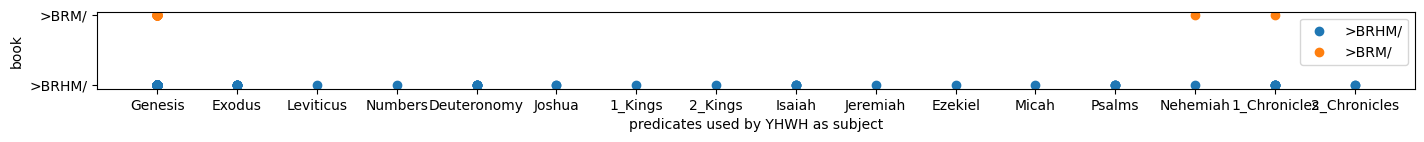

In [16]:
fig, ax = plt.subplots()
fig.set_size_inches(17, 1)

for S1, df in BHSAbrahamSearch.groupby('lex1'):
    ax.scatter(x="S1", y="lex1", data=df, label=S1)

ax.set_xlabel("predicates used by YHWH as subject")
ax.set_ylabel("book")
ax.legend();

## Simple ImPlotting with Seaborn

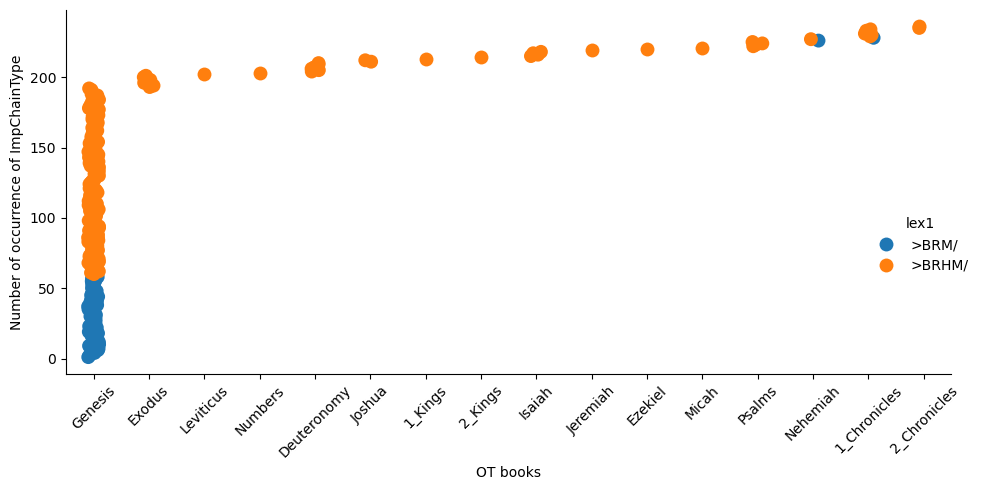

In [17]:
g = sns.catplot(x="S1", y="R", data=BHSAbrahamSearch, hue='lex1',
                kind="strip", height=5, aspect=7/4, s=100)

g.set_axis_labels('OT books', 'Number of occurrence of ImpChainType')
g.set_xticklabels(rotation=45)
plt.tight_layout()

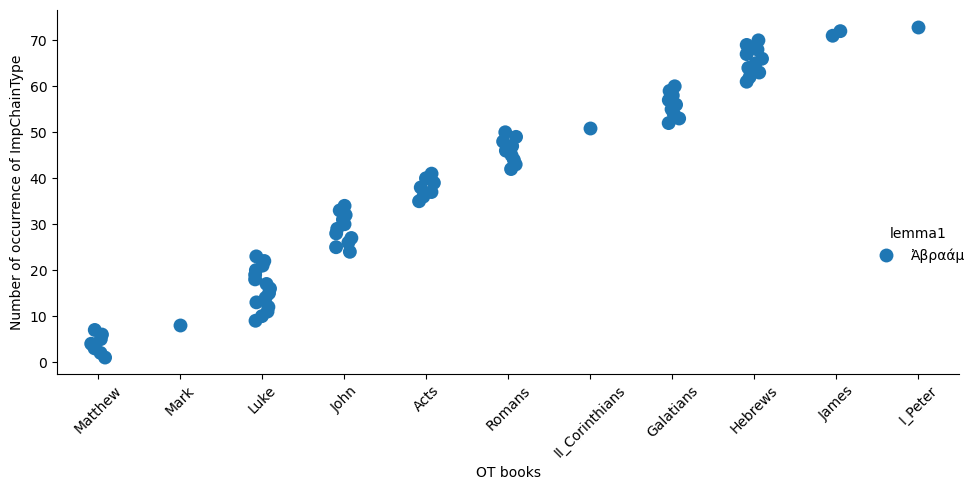

In [18]:
g = sns.catplot(x="S1", y="R", data=NTAbrahamSearch, hue='lemma1',
                kind="strip", height=5, aspect=7/4, s=100)

g.set_axis_labels('OT books', 'Number of occurrence of ImpChainType')
g.set_xticklabels(rotation=45)
plt.tight_layout()

## Simple Pie-Plotting

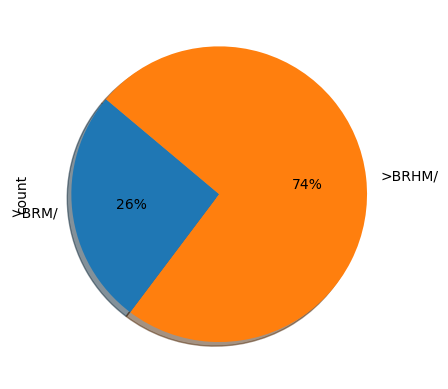

In [19]:
BHSAbrahamSearch.lex1.value_counts(sort=False).plot.pie(autopct='%1.0f%%', shadow=True, startangle=140)
plt.show()

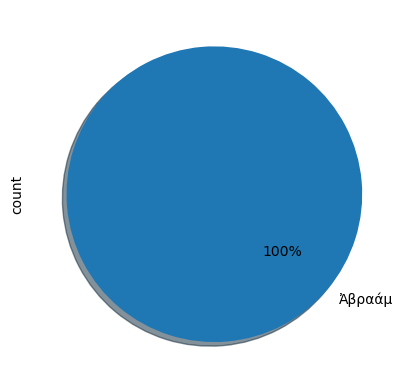

In [20]:
NTAbrahamSearch.lemma1.value_counts(sort=False).plot.pie(autopct='%1.0f%%', shadow=True, startangle=140)
plt.show()

# Assignments

1. Import one of your own TF queries form the previous assignment (previous tutorial) and import it as a pandas dataframe.
2. Experiment with the different data-mining options you have learned in this notebook.
3. Make a simple plot of your choice to represent your query result.

# Whats Next?: Complex Query building
1. We will build VocabLists for Hebrew and Greek courses that you have to teach in the future.
2. We will us the remaining time to get issues and questions resolved.
3. We will learn the basic architecture of the BHS and the Tischendorf database.
4. Understanding the database better will allow us to build sophisticated queries, including syntax queries...